In [1]:
#create 100 random point 
import numpy as np
X = 2 * np.random.rand(100,1)
y = 4 + 3*X+ np.random.randn(100,1)

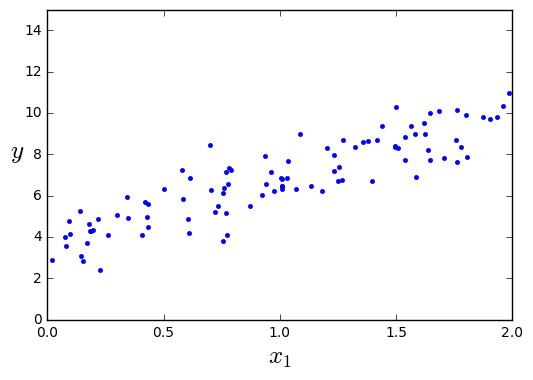

In [2]:
import matplotlib
import matplotlib.pyplot as plt
plt.plot(X, y,"b.")
plt.xlabel("$x_1$", fontsize = 18)
plt.ylabel("$y$", rotation = 0, fontsize =18)
plt.axis([0,2,0,15])
plt.savefig("Generated data plot")
plt.show()

In [3]:
X_b = np.c_[np.ones((100,1)),X] #add x0 = 1 to each X
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)


In [4]:
theta_best

array([[ 3.65961676],
       [ 3.17129982]])

In [5]:
#now we make prediction using theta_best
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)), X_new]
y_predict = X_new_b.dot(theta_best)

In [7]:
y_predict

array([[ 3.7606773 ],
       [ 9.74029664]])

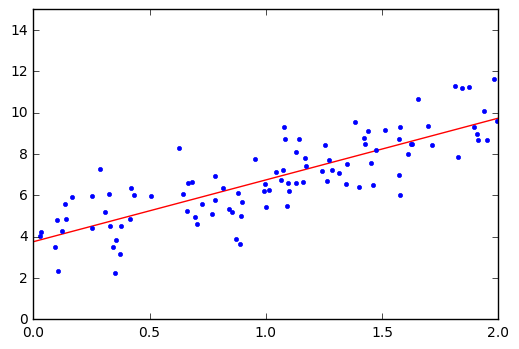

In [8]:
#now we plot the new point
plt.plot(X_new,y_predict,"r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

In [6]:
#now we use sklearn to check
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

In [10]:
#check the coefficient
lin_reg.intercept_, lin_reg.coef_

(array([ 3.7606773]), array([[ 2.98980967]]))

In [7]:
lin_reg.predict(X_new)

array([[  3.65961676],
       [ 10.0022164 ]])

follow code for Gradient Descend

In [8]:
eta = 0.1 #learning rate
n_iterations = 1000
m = 100 #number of point

In [9]:
theta = np.random.randn(2,1) #random initialization

In [10]:
for iteration in range(n_iterations):
    gradient = 2/m * X_b.T.dot(X_b.dot(theta)-y)
    theta = theta - eta*gradient

In [15]:
theta

array([[ 3.7606773 ],
       [ 2.98980967]])

In [11]:
#test our model
X_new_b.dot(theta)

array([[  3.65961676],
       [ 10.0022164 ]])

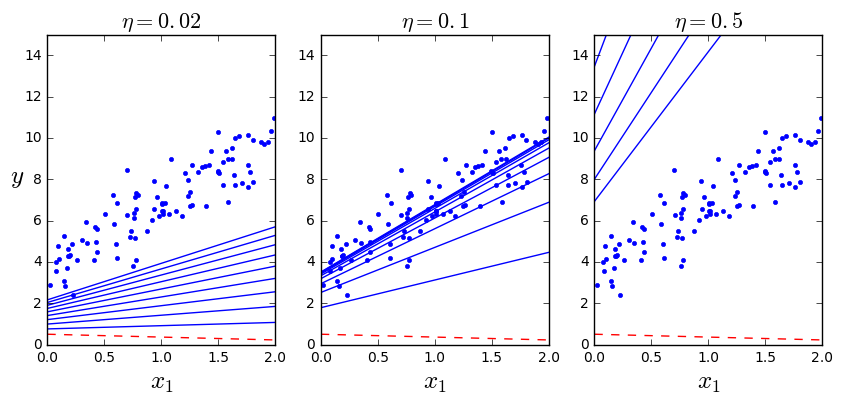

In [12]:
theta_path_bgd = []

def plot_gradient_descent(theta, eta, theta_path=None):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_iterations = 1000
    for iteration in range(n_iterations):
        if iteration < 10:
            y_predict = X_new_b.dot(theta)
            style = "b-" if iteration > 0 else "r--"
            plt.plot(X_new, y_predict, style)
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        if theta_path is not None:
            theta_path.append(theta)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta = {}$".format(eta), fontsize=16)

np.random.seed(42)
theta = np.random.randn(2,1)  # random initialization

plt.figure(figsize=(10,4))
plt.subplot(131); plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(132); plot_gradient_descent(theta, eta=0.1, theta_path=theta_path_bgd)
plt.subplot(133); plot_gradient_descent(theta, eta=0.5)

#save_fig("gradient_descent_plot")
plt.show()

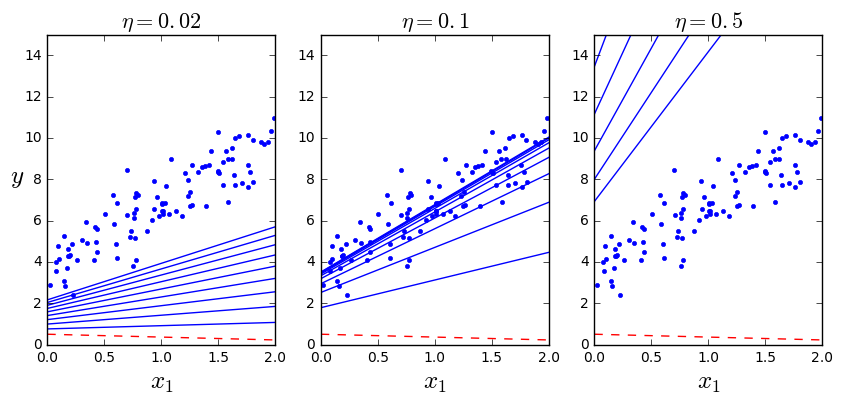

In [13]:
np.random.seed(42)
theta = np.random.randn(2,1)  # random initialization

plt.figure(figsize=(10,4))
plt.subplot(131); plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(132); plot_gradient_descent(theta, eta=0.1, theta_path=theta_path_bgd)
plt.subplot(133); plot_gradient_descent(theta, eta=0.5)

#save_fig("gradient_descent_plot")
plt.show()

Stochastic Gredient Descent

In [14]:
n_epochs = 50
t0, t1 = 5,50 #learning schedule hyperparameters

In [15]:
def learning_schedule(t):
    return t0/(t+t1)

In [16]:
theta = np.random.randn(2,1) #random initialization

In [17]:
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index: random_index + 1]
        yi = y[random_index:random_index + 1]
        gradients = 2*xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m +i)
        theta = theta - eta*gradients

In [23]:
theta

array([[ 3.82941577],
       [ 2.94399431]])

now test with build-in library of scikit learn

In [18]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(n_iter = 50, penalty = None, eta0 = 0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(alpha=0.0001, average=False, epsilon=0.1, eta0=0.1,
       fit_intercept=True, l1_ratio=0.15, learning_rate='invscaling',
       loss='squared_loss', n_iter=50, penalty=None, power_t=0.25,
       random_state=None, shuffle=True, verbose=0, warm_start=False)

In [25]:
#coefficient 
sgd_reg.intercept_, sgd_reg.coef_

(array([ 3.83773118]), array([ 3.08255677]))

Polymial Regression

In [19]:
#create 2 degree polyminial
#number of point 
m = 100
X = 6*np.random.rand(m,1) - 3
y = 0.5*X**2 + X + 2 + np.random.randn(m,1)

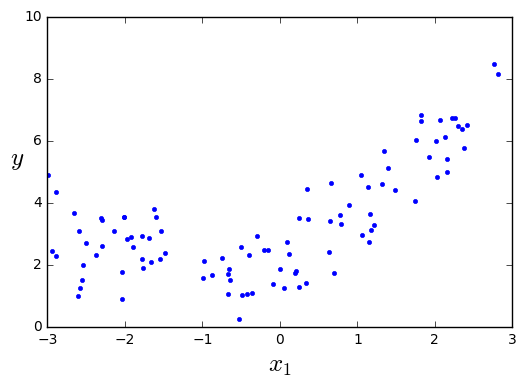

In [20]:
import matplotlib
import matplotlib.pyplot as plt
plt.plot(X,y,"b.")
plt.axis([-3,3,0,10])
plt.xlabel("$x_1$", fontsize = 18)
plt.ylabel("$y$", rotation = 0, fontsize =18)
plt.savefig("Polyminal Regression : Generate data point")
plt.show()

In [21]:
#test scikit learn lib of polyminal 
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree = 2, include_bias = False)
X_poly = poly_features.fit_transform(X)

In [22]:
X[0]

array([ 2.15290063])

In [23]:
X_poly[0]

array([ 2.15290063,  4.63498111])

In [24]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

In [32]:
lin_reg.intercept_

array([ 2.28405711])

In [33]:
lin_reg.coef_

array([[ 0.88171323,  0.44446033]])

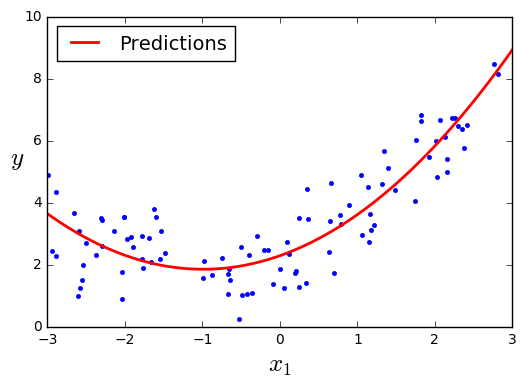

In [25]:
#plot the results
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$",rotation = 0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.savefig("quadratic_predictions_plot")
plt.show()

try with polynimial 300th degree

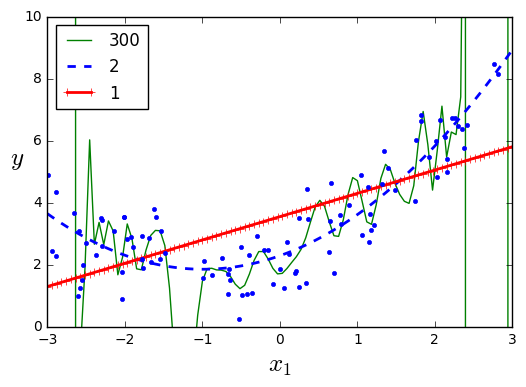

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

for style, width, degree in (("g-", 1, 300), ("b--", 2, 2), ("r-+", 2, 1)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.savefig("high_degree_polynomials_plot")
plt.show()

In [27]:
#learning curves
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
#plot function 
def plot_learning_curves(model, X,y):
    X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2)
    train_errors, val_errors = [],[]
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train_predict, y_train[:m]))
        val_errors.append(mean_squared_error(y_val_predict, y_val))
    plt.plot(np.sqrt(train_errors),"r-+", linewidth = 2)
    plt.plot(np.sqrt(val_errors),"b-", linewidth = 3, label = "val")

In [28]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X,y)

In [38]:
plt.xlabel("Training test size")
plt.ylabel("RMSE")
plt.axis([0, 80, 0, 3])
plt.savefig("Learning curves")

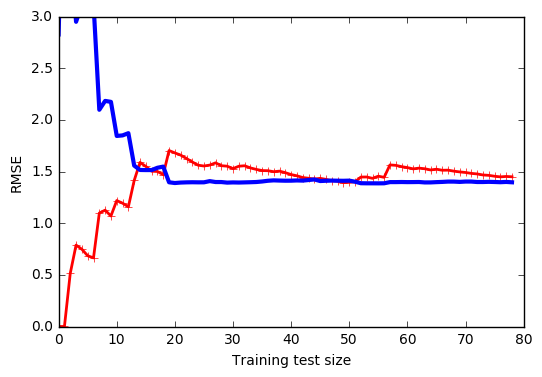

In [39]:
plt.show()

In [29]:
#now instead of linear regression, we use 10th degree 
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline((
        ("poly_features", PolynomialFeatures(degree = 10, include_bias = False)),
        ("sgd_reg", LinearRegression())))

In [30]:
plot_learning_curves(polynomial_regression, X,y)
plt.xlabel("Training test size")
plt.ylabel("RMSE")
plt.axis([0, 80, 0, 3])
plt.savefig("Learning curves")

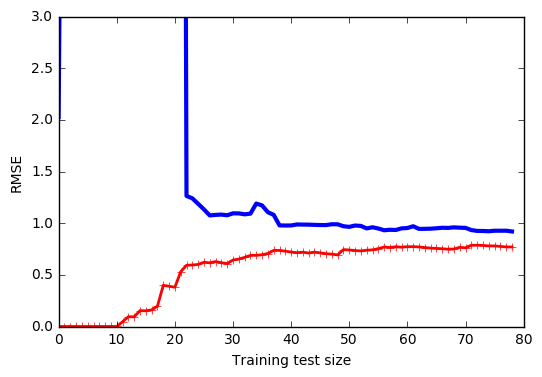

In [42]:
plt.show()

In [31]:
#test Ridge Regression
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha = 1, solver  = "cholesky")
ridge_reg.fit(X,y)

Ridge(alpha=1, copy_X=True, fit_intercept=True, max_iter=None,
   normalize=False, random_state=None, solver='cholesky', tol=0.001)

In [32]:
ridge_reg.predict([[1.5]])

array([[ 4.66784461]])